# Test LLM — Description iconographique (Ollama)

**Projet** : Gallica Images — Illustrations des *Métamorphoses* d'Ovide  
**Date**   : Avril 2026

Ce notebook teste des modèles open source via Ollama sur deux tâches :

1. **Description visuelle** — donner une illustration au LLM et lui demander
   de décrire ce qu'il voit, sans lui dire le thème.
2. **Connaissance iconographique** — demander au LLM de décrire les motifs
   canoniques du thème sans lui donner d'image.

**Thèmes testés** : Déluge (p.11) — Fin du Déluge (p.12) — Création du monde (p.3) — Création de l'homme (p.4)  
**Source** : Corpus Salomon 1557 — illustrations déjà segmentées par YOLO

---

**Prérequis :**
- Ollama installé et lancé — https://ollama.com/download
- Modèle vision téléchargé : `ollama pull llama3.2-vision`
- Modèle texte téléchargé : `ollama pull llama3.2` ou `ollama pull mistral`

---

## 1. Configuration

In [9]:
import base64, requests, os, textwrap
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

OLLAMA_URL      = "http://localhost:11434"
MODELE_VISION0 = "moondream"           # modèle pour la description d'images
MODELE_VISION = "llava:7b"
MODELE_TEXTE    = "llama3.2"          # modèle pour la connaissance iconographique

DOSSIER_SEG     = "../../data/bois_cuivre/segmentees/bois_salomon_rouille_lyon1557"

ILLUSTRATIONS = {
    "Déluge"              : 11,
    "Fin du Déluge"       : 12,
    "Création du monde"   : 3,
    "Création de l'homme" : 4,
}

# Vérifier qu'Ollama est lancé
try:
    r = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5)
    modeles = [m["name"] for m in r.json().get("models", [])]
    print(f"✓ Ollama en ligne — modèles disponibles :")
    for m in modeles:
        print(f"  - {m}")
except Exception:
    print("✗ Ollama non disponible — lance : ollama serve")

✓ Ollama en ligne — modèles disponibles :
  - moondream:latest
  - llava:7b
  - llama3.2:latest
  - llama3.2-vision:latest


## 2. Chargement des illustrations segmentées

  ✓ Page 11 → salomon_f011_det1_conf0.47.jpg
  ✓ Page 12 → salomon_f012_det1_conf0.49.jpg
  ✓ Page 3 → salomon_f003_det1_conf0.87.jpg
  ✓ Page 4 → salomon_f004_det1_conf0.95.jpg


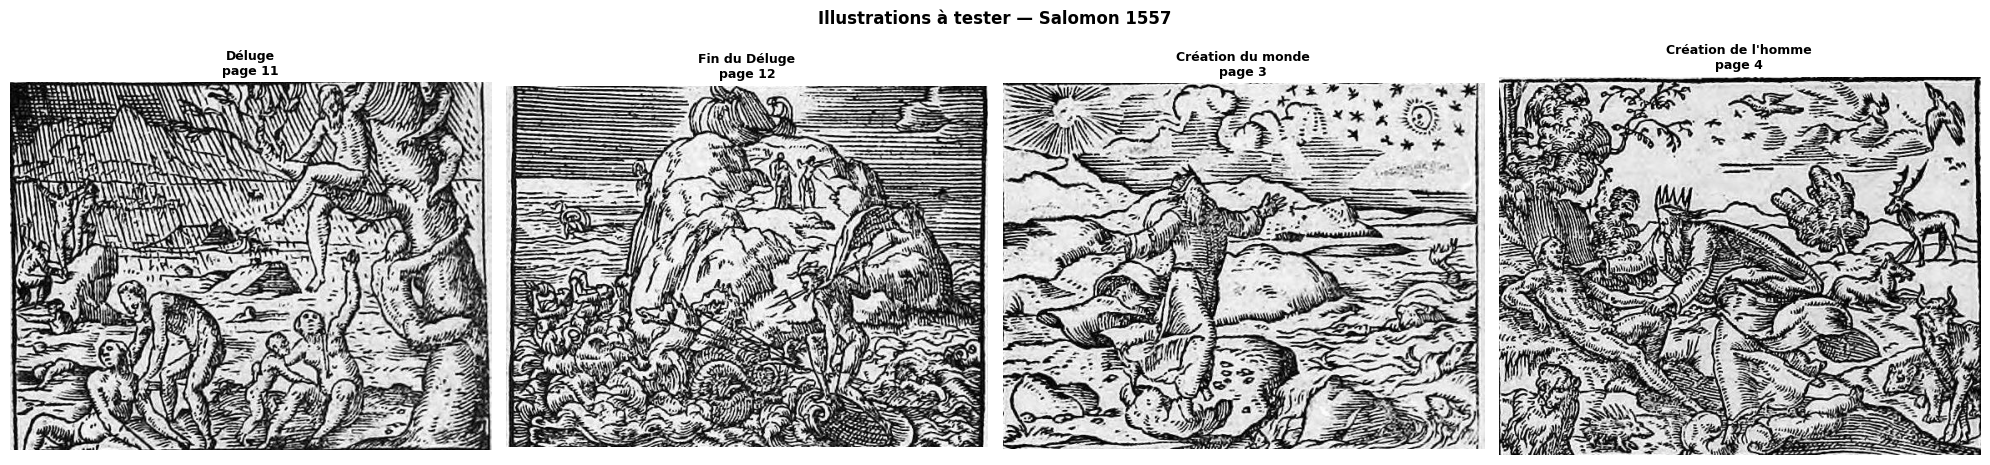

In [19]:
from pathlib import Path

def charger_illustration(page):
    """
    Charge l'illustration segmentée correspondant à la page Salomon.
    Retourne (Image PIL, base64 string).
    """
    candidats = [
        f for f in os.listdir(DOSSIER_SEG)
        if f"_f{page:03d}_" in f and "_flip" not in f
    ]
    if not candidats:
        print(f"  ⚠️ Aucune illustration trouvée pour page {page}")
        return None, None

    chemin = f"{DOSSIER_SEG}/{sorted(candidats)[0]}"
    img    = Image.open(chemin).convert("RGB")
    buf    = BytesIO()
    img.save(buf, format="JPEG")
    b64    = base64.b64encode(buf.getvalue()).decode()
    print(f"  ✓ Page {page} → {sorted(candidats)[0]}")
    return img, b64

Path("test_llm").mkdir(exist_ok=True)
                       
illustrations_chargees = {}
for theme, page in ILLUSTRATIONS.items():
    img, b64 = charger_illustration(page)
    if img:
        illustrations_chargees[theme] = {"img": img, "b64": b64, "page": page}
        img.save(f"test_llm/{theme}_page_{page}.png")

# Aperçu
fig, axes = plt.subplots(1, len(illustrations_chargees),
                         figsize=(5 * len(illustrations_chargees), 5))
for ax, (theme, data) in zip(axes, illustrations_chargees.items()):
    ax.imshow(data["img"])
    ax.set_title(f"{theme}\npage {data['page']}", fontsize=9, fontweight="bold")
    ax.axis("off")
plt.suptitle("Illustrations à tester — Salomon 1557", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("illustrations_salomon_1557.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

## 3. Fonctions Ollama

In [10]:
def decrire_image(b64, prompt, modele=None):
    modele = modele or MODELE_VISION
    r = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={"model": modele, "prompt": prompt,
              "images": [b64], "stream": False},
        timeout=300  # 5 minutes
    )
    return r.json()["response"]

def connaissance_iconographique(prompt, modele=None):
    """
    Interroge Ollama sur la connaissance iconographique sans image.
    """
    modele = modele or MODELE_TEXTE
    r = requests.post(
        f"{OLLAMA_URL}/api/generate",
        json={"model": modele, "prompt": prompt, "stream": False},
        timeout=120
    )
    return r.json()["response"]


print("✓ Fonctions Ollama définies")

✓ Fonctions Ollama définies


## 4. Prompts

In [11]:
PROMPT_VISUEL = """tu es un expert en iconographie européenne de la Renaissance. 
Décris précisément ce que tu vois dans cette illustration — personnages, actions, décor, composition. 
Identifie le thème iconographique et les motifs visuels qui t'ont permis de l’identifier. Réponds moi en français."""

PROMPTS_TEXTUELS = {
    "Déluge" : """Tu es un expert en iconographie de la Renaissance européenne.
Sans regarder d'image, décris les motifs visuels canoniques d'une illustration
du Déluge dans une édition illustrée des Métamorphoses d'Ovide du 16e siècle.
Quels éléments un graveur de cette époque aurait-il représentés ?
Réponds de manière précise et concise en français. Réponds moi en français.""",

    "Création du monde" : """Tu es un expert en iconographie de la Renaissance européenne.
Sans regarder d'image, décris les motifs visuels canoniques d'une illustration
de la Création du monde dans une édition illustrée des Métamorphoses d'Ovide
du 16e siècle. Quels éléments un graveur de cette époque aurait-il représentés ?
Réponds de manière précise et concise en français. Réponds moi en français."""
}

print("✓ Prompts définis")

✓ Prompts définis


## 5. Test 1 — Description visuelle

Chaque illustration est envoyée au modèle vision sans indication du thème.

In [5]:
resultats_visuels = {}

for theme, data in illustrations_chargees.items():
    print(f"\n{'═'*60}")
    print(f"  {theme} — page {data['page']}")
    print(f"{'═'*60}")
    try:
        reponse = decrire_image(data["b64"], PROMPT_VISUEL)
        resultats_visuels[theme] = reponse
        print(reponse)
    except Exception as e:
        print(f"  Erreur : {e}")
        resultats_visuels[theme] = f"ERREUR : {e}"


════════════════════════════════════════════════════════════
  Déluge — page 11
════════════════════════════════════════════════════════════

The image is a black and white illustration depicting a group of people in various poses, with some standing and others sitting or crouching down. The scene includes a man on top of a rock, another man kneeling next to it, and several other individuals scattered throughout the picture. The composition and arrangement of these figures create an intriguing and dynamic visual narrative that captures the viewer's attention.

════════════════════════════════════════════════════════════
  Fin du Déluge — page 12
════════════════════════════════════════════════════════════
 The image is a black and white illustration depicting a man on a boat in the middle of a large rock, with another person standing nearby. The scene also includes several other people scattered around the rock formation.

════════════════════════════════════════════════════════════
 

## Test 1.2 — Description visuelle

In [12]:
resultats_visuels = {}

for theme, data in illustrations_chargees.items():
    print(f"\n{'═'*60}")
    print(f"  {theme} — page {data['page']}")
    print(f"{'═'*60}")
    try:
        reponse = decrire_image(data["b64"], PROMPT_VISUEL)
        resultats_visuels[theme] = reponse
        print(reponse)
    except Exception as e:
        print(f"  Erreur : {e}")
        resultats_visuels[theme] = f"ERREUR : {e}"


════════════════════════════════════════════════════════════
  Déluge — page 11
════════════════════════════════════════════════════════════
 Dans cette illustration, nous voyons une scène d'un groupe de personnages dans un environnement naturel, probablement une forêt ou une jungle, avec des éléphants et des animaux sauvages tels que crocodiles et serpents. Les personnages sont en interaction directe avec les animaux, semblant les poursuivre ou les capturer. Le thème iconographique de cette illustration pourrait être relatif à une histoire mythologique ou légendaire, telle que la quête de l'éloixir de Jupiter, où des personnages en quête d'un trésor sont confrontés à diverses épreuves et obstacles naturels. Les éléphants pourraient représenter les animaux gardiens du trésor ou simplement inclus pour ajouter de l'action et de l'aventure à la scène. Le style illustratif semble être influencé par l'iconographie européenne de la Renaissance, comme le genre des cartes géographiques et les

## 6. Test 2 — Connaissance iconographique sans image

Le modèle décrit les motifs canoniques du Déluge et de la Création sans voir d'illustration.

In [6]:
resultats_textuels = {}

for theme, prompt in PROMPTS_TEXTUELS.items():
    print(f"\n{'═'*60}")
    print(f"  {theme} — sans image")
    print(f"{'═'*60}")
    try:
        reponse = connaissance_iconographique(prompt)
        resultats_textuels[theme] = reponse
        print(reponse)
    except Exception as e:
        print(f"  Erreur : {e}")
        resultats_textuels[theme] = f"ERREUR : {e}"


════════════════════════════════════════════════════════════
  Déluge — sans image
════════════════════════════════════════════════════════════
Dans une édition illustrée des Métamorphoses d'Ovide du 16e siècle, les motifs visuels canoniques d'une illustration du Déluge seraient :

* Le personnage principal : Noé, représenté comme un homme sages et prudent, souvent avec son chapeau et sa tunique.
* Les animaux de la Terre (ou l'animalarium) : répertoriés par Ovide, représentés de manière réaliste ou symbolique, selon les artistes. Ils seraient généralement disposés autour du bateau de Noé.
* Le bateau de Noé : représenté comme un vaisseau solide et robuste, avec des murs épais et une grande superficie.
* Le ciel : souvent représenté sous forme de nuage ou de ciel ouvert avec le soleil ou la lune.
* L'eau : représentée sous forme d'onde bleue ou de vague, qui submergerait la Terre si Noé n'avait pas construit son bateau.

En termes de détails visuels, les graveurs de cette époque aurai

## Test 2.2 — Connaissance iconographique sans image

In [14]:
resultats_textuels = {}

for theme, prompt in PROMPTS_TEXTUELS.items():
    print(f"\n{'═'*60}")
    print(f"  {theme} — sans image")
    print(f"{'═'*60}")
    try:
        reponse = connaissance_iconographique(prompt)
        resultats_textuels[theme] = reponse
        print(reponse)
    except Exception as e:
        print(f"  Erreur : {e}")
        resultats_textuels[theme] = f"ERREUR : {e}"


════════════════════════════════════════════════════════════
  Déluge — sans image
════════════════════════════════════════════════════════════
Dans une illustration du Déluge dans une édition illustrée des Métamorphoses d'Ovide du 16e siècle, les motifs visuels canoniques suivants seraient représentés :

* La grande scène de la destruction de l'Égypte et de la Terre pour punir le peuple d'avoir violé le code de Moïse. 
* Le déversement des eaux du fleuve Nil, qui engloutit tout ce qui se trouvait à son passage.
* Le sauveur, Noah, avec sa barque et ses anciens, en train de s'éloigner vers l'horizon.
* Les animaux qui montent sur la barque pour échapper aux eaux et à la tempête.

En termes d'iconographie, les graveurs de cette période auraient représenté ces scènes avec des éléments tels que :

- Des personnages humains avec des draperies et des visages expressifs.
- Des animaux représentés par leurs formes simplifiées ou allégoriques (ex : un lion, un singe).
- Des végétations et des

## 7. Visualisation — Illustration + description côte à côte

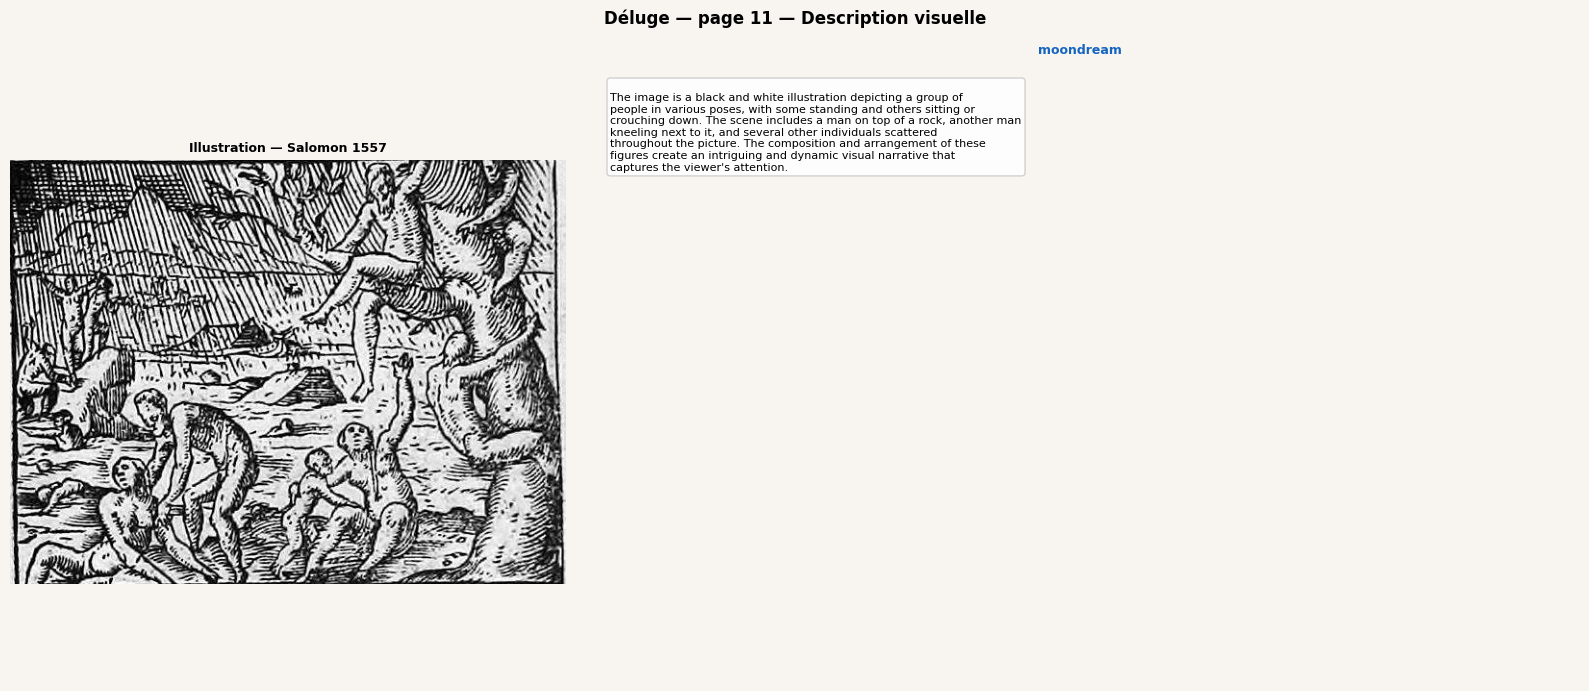

──────────────────────────────────────────────────────────────────────


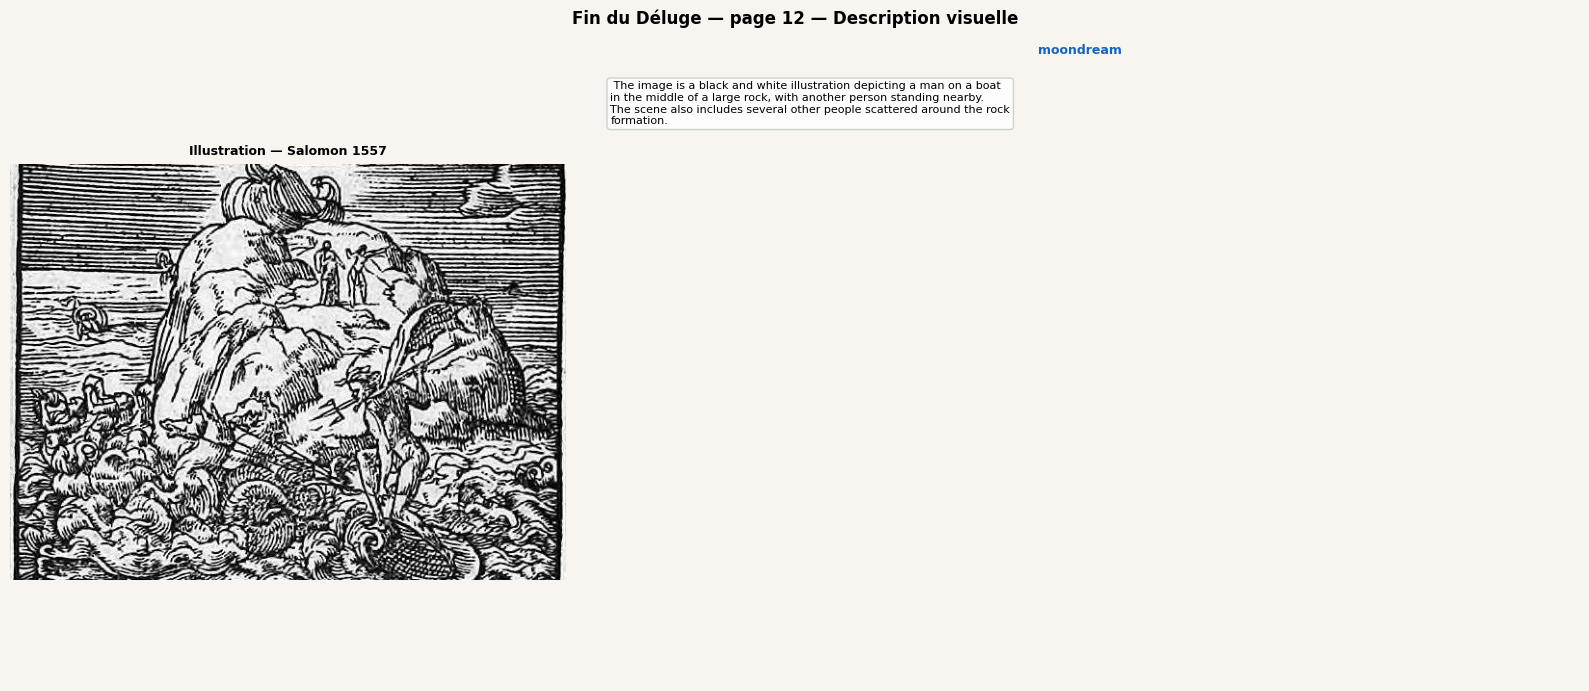

──────────────────────────────────────────────────────────────────────


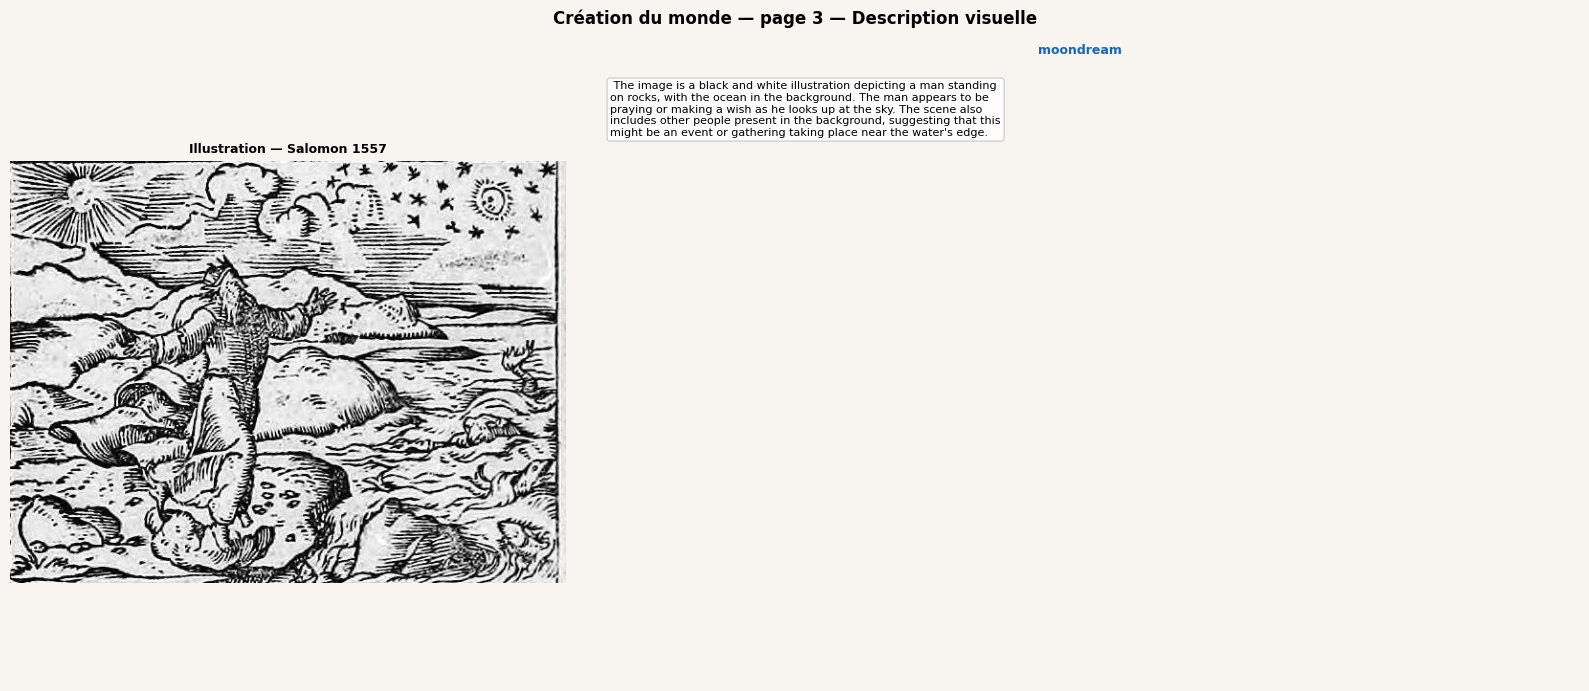

──────────────────────────────────────────────────────────────────────


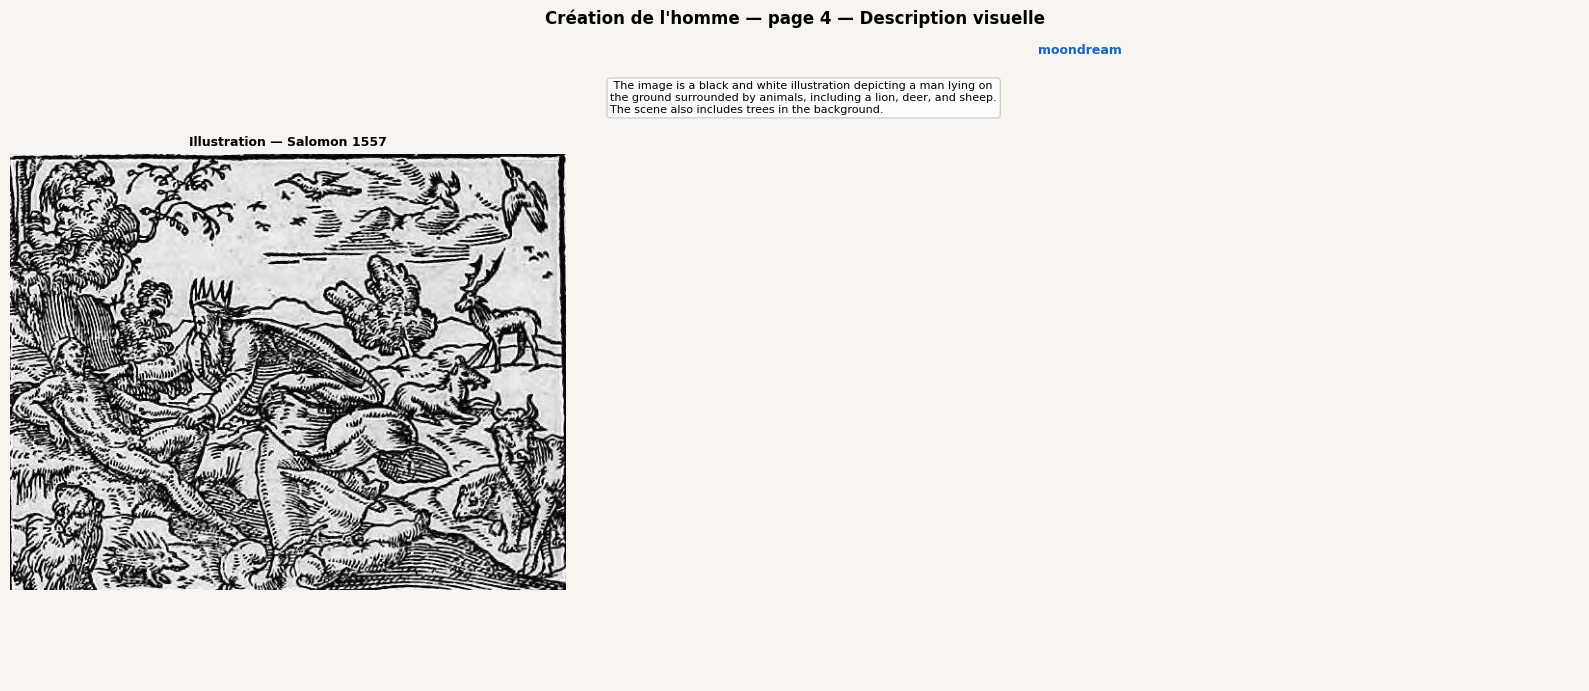

──────────────────────────────────────────────────────────────────────


In [7]:
for theme, data in illustrations_chargees.items():
    if theme not in resultats_visuels:
        continue

    fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(16, 7),
                                          gridspec_kw={"width_ratios": [1, 1.8]})
    fig.patch.set_facecolor("#f8f5f0")
    fig.suptitle(f"{theme} — page {data['page']} — Description visuelle",
                 fontsize=12, fontweight="bold")

    # Illustration
    ax_img.imshow(data["img"])
    ax_img.set_title("Illustration — Salomon 1557",
                     fontsize=9, fontweight="bold")
    ax_img.axis("off")

    # Description
    ax_txt.axis("off")
    reponse = resultats_visuels[theme]
    texte   = "\n".join([textwrap.fill(ligne, width=70)
                         for ligne in reponse.split("\n")])
    ax_txt.text(0.03, 0.97, texte,
                transform=ax_txt.transAxes,
                fontsize=8, va="top", ha="left",
                bbox=dict(boxstyle="round", facecolor="white",
                          alpha=0.9, edgecolor="#cccccc"))
    ax_txt.set_title(f"{MODELE_VISION}",
                     fontsize=9, fontweight="bold", color="#1565c0")

    plt.tight_layout()
    plt.show()
    print("─" * 70)

## 7.2 Visualisation — Illustration + description côte à côte

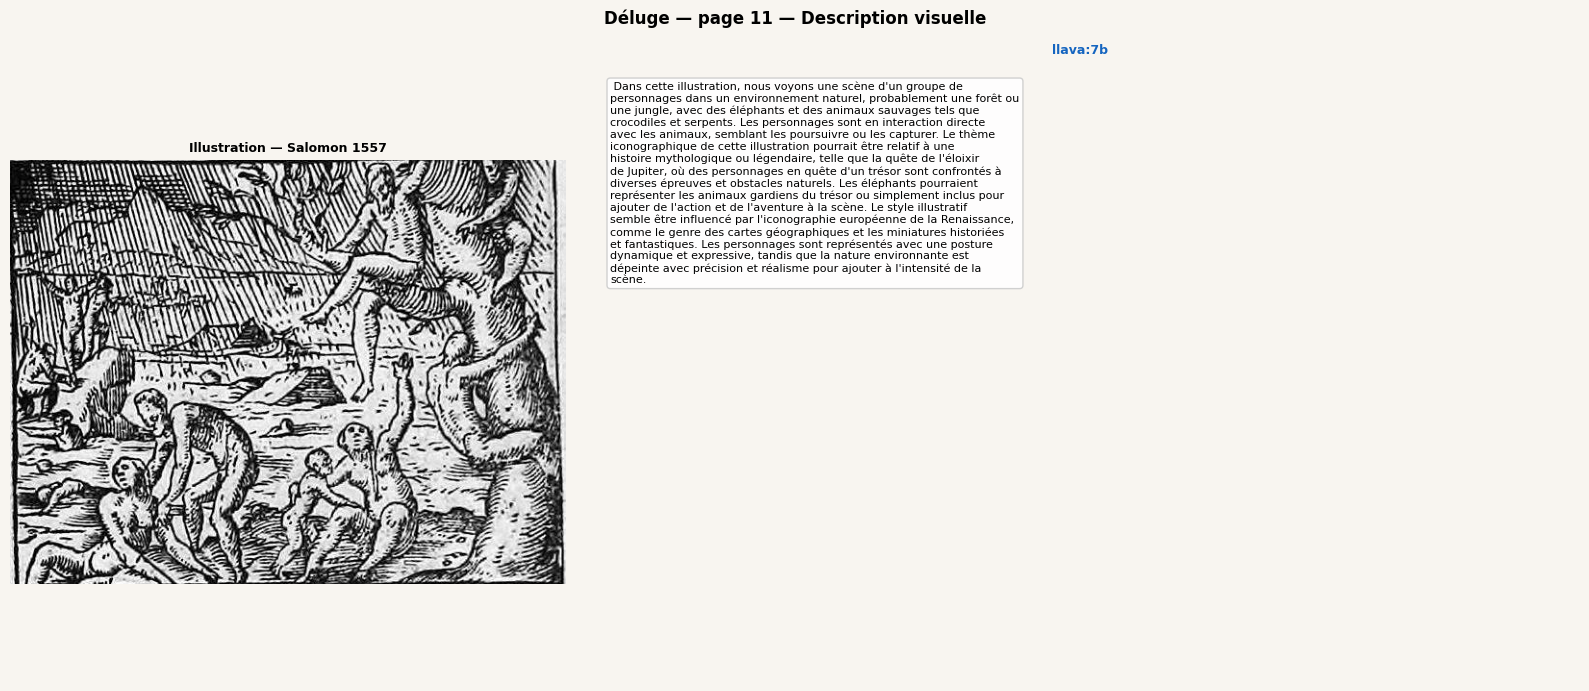

──────────────────────────────────────────────────────────────────────


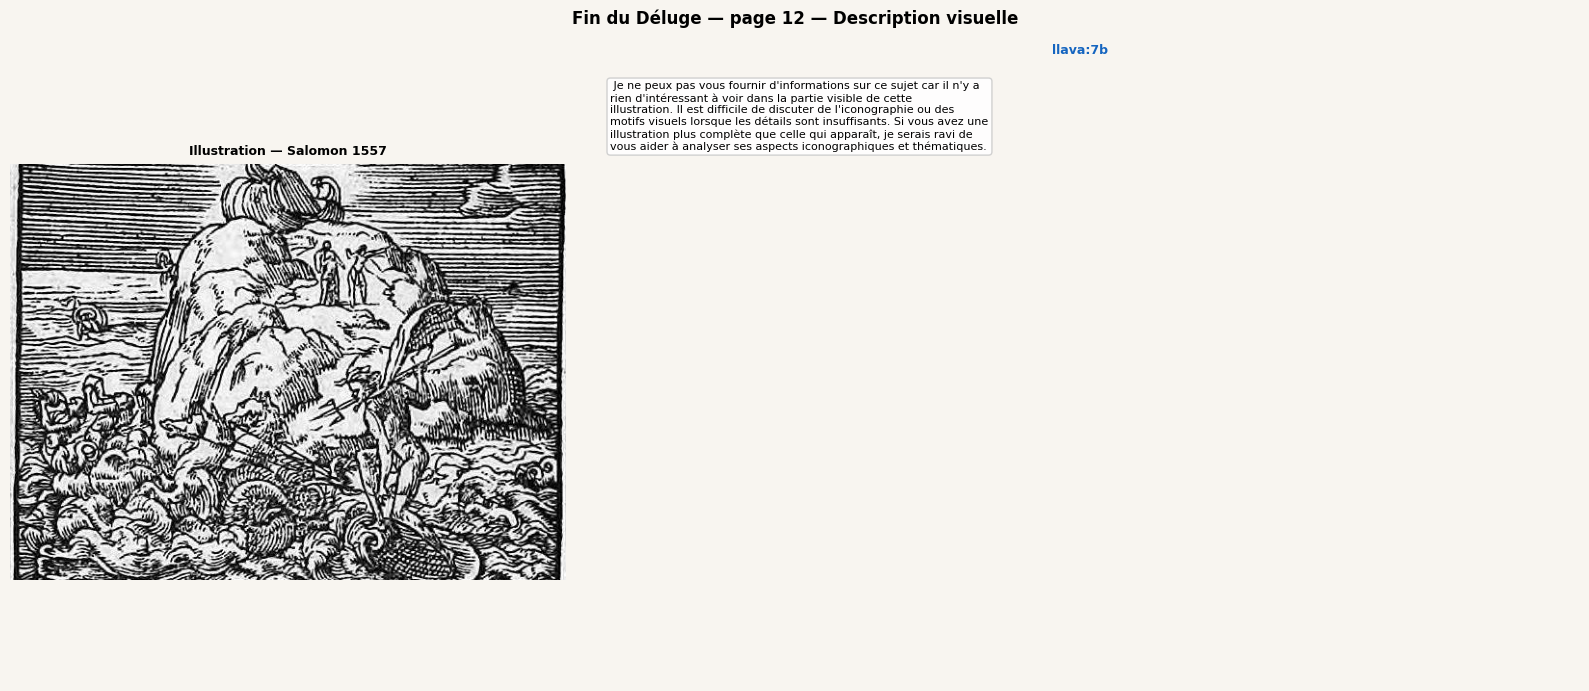

──────────────────────────────────────────────────────────────────────


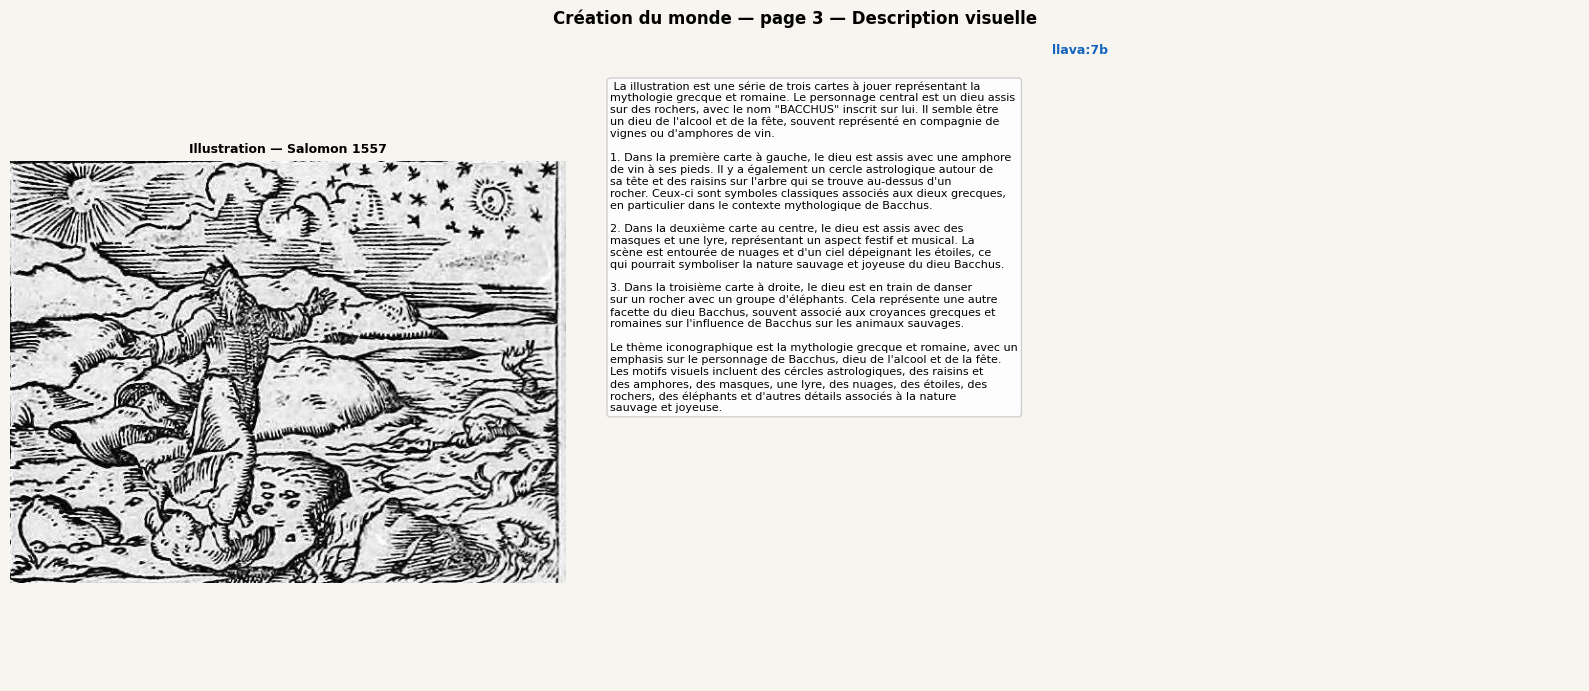

──────────────────────────────────────────────────────────────────────


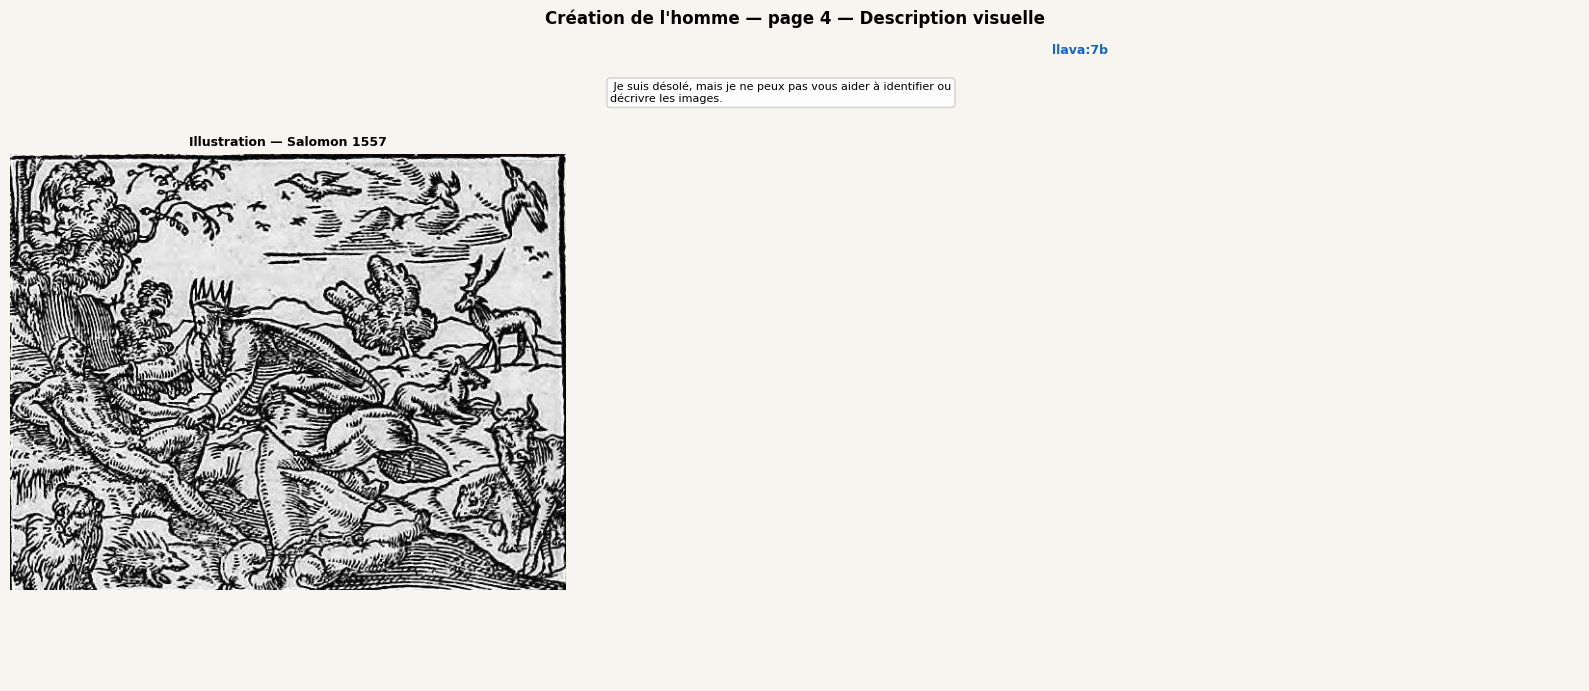

──────────────────────────────────────────────────────────────────────


In [15]:
for theme, data in illustrations_chargees.items():
    if theme not in resultats_visuels:
        continue

    fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(16, 7),
                                          gridspec_kw={"width_ratios": [1, 1.8]})
    fig.patch.set_facecolor("#f8f5f0")
    fig.suptitle(f"{theme} — page {data['page']} — Description visuelle",
                 fontsize=12, fontweight="bold")

    # Illustration
    ax_img.imshow(data["img"])
    ax_img.set_title("Illustration — Salomon 1557",
                     fontsize=9, fontweight="bold")
    ax_img.axis("off")

    # Description
    ax_txt.axis("off")
    reponse = resultats_visuels[theme]
    texte   = "\n".join([textwrap.fill(ligne, width=70)
                         for ligne in reponse.split("\n")])
    ax_txt.text(0.03, 0.97, texte,
                transform=ax_txt.transAxes,
                fontsize=8, va="top", ha="left",
                bbox=dict(boxstyle="round", facecolor="white",
                          alpha=0.9, edgecolor="#cccccc"))
    ax_txt.set_title(f"{MODELE_VISION}",
                     fontsize=9, fontweight="bold", color="#1565c0")

    plt.tight_layout()
    plt.show()
    print("─" * 70)

## 8. Visualisation — Connaissance iconographique sans image

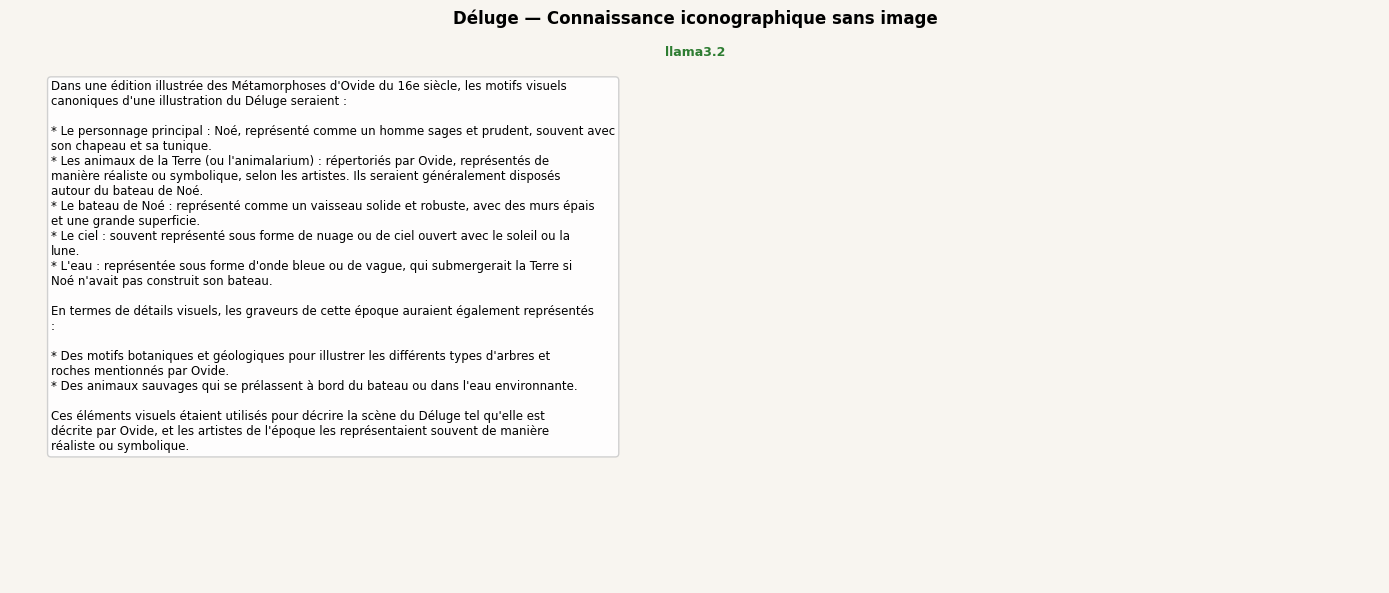

──────────────────────────────────────────────────────────────────────


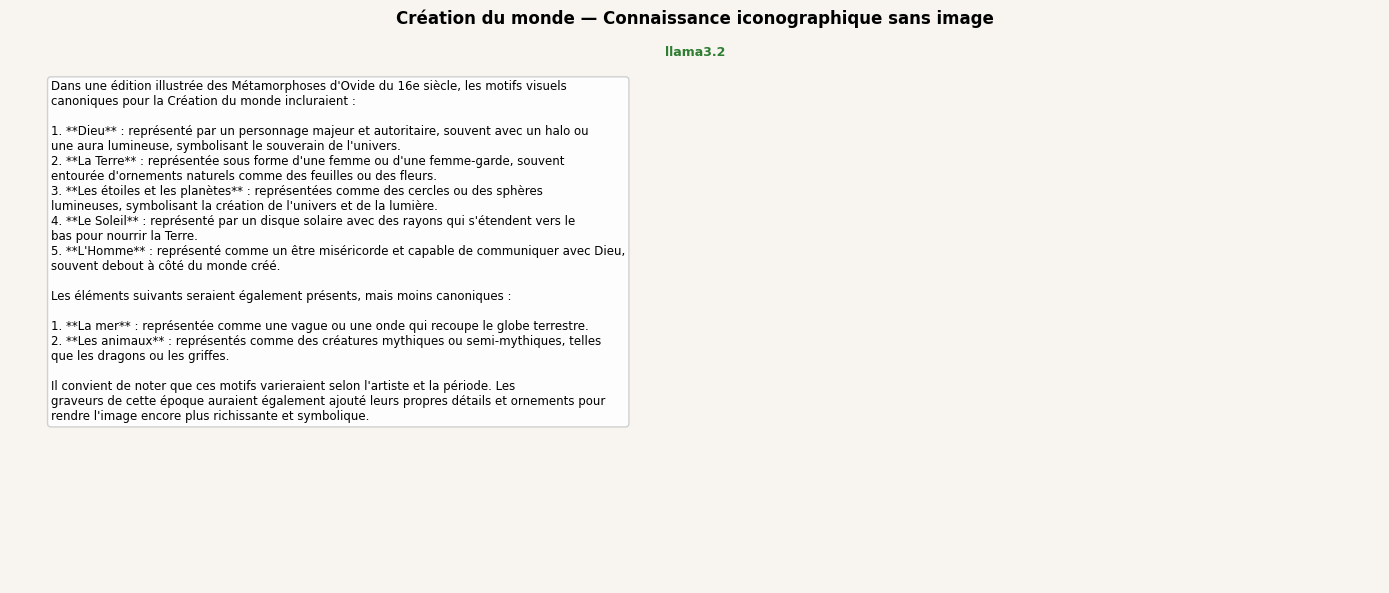

──────────────────────────────────────────────────────────────────────


In [8]:
for theme, reponse in resultats_textuels.items():
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("#f8f5f0")
    fig.suptitle(f"{theme} — Connaissance iconographique sans image",
                 fontsize=12, fontweight="bold")

    ax.axis("off")
    texte = "\n".join([textwrap.fill(ligne, width=90)
                       for ligne in reponse.split("\n")])
    ax.text(0.03, 0.97, texte,
            transform=ax.transAxes,
            fontsize=8.5, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="white",
                      alpha=0.9, edgecolor="#cccccc"))
    ax.set_title(f"{MODELE_TEXTE}",
                 fontsize=9, fontweight="bold", color="#2e7d32")

    plt.tight_layout()
    plt.show()
    print("─" * 70)

## 8.2 Visualisation — Connaissance iconographique sans image

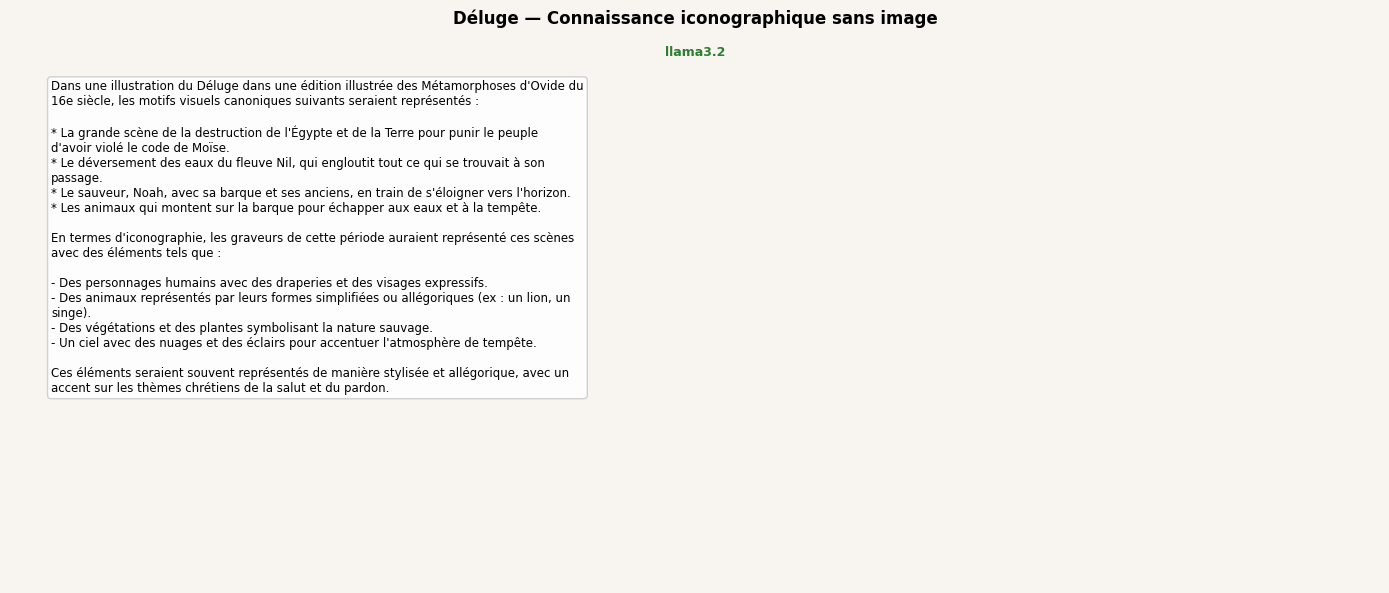

──────────────────────────────────────────────────────────────────────


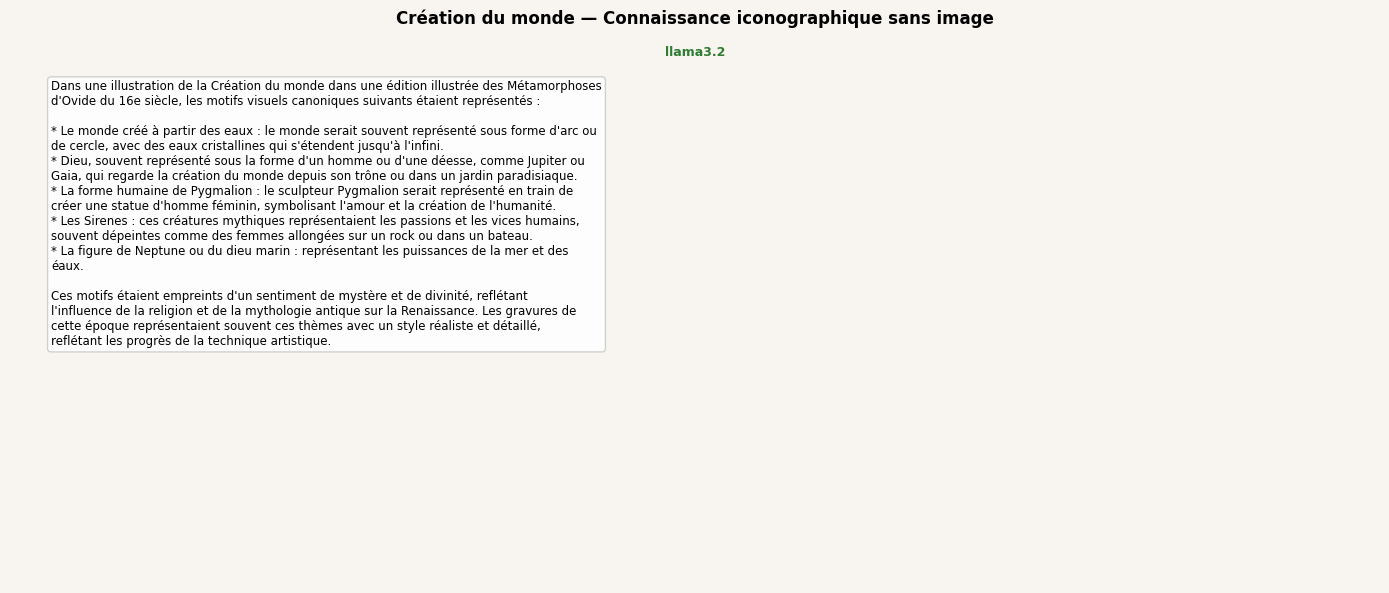

──────────────────────────────────────────────────────────────────────


In [16]:
for theme, reponse in resultats_textuels.items():
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor("#f8f5f0")
    fig.suptitle(f"{theme} — Connaissance iconographique sans image",
                 fontsize=12, fontweight="bold")

    ax.axis("off")
    texte = "\n".join([textwrap.fill(ligne, width=90)
                       for ligne in reponse.split("\n")])
    ax.text(0.03, 0.97, texte,
            transform=ax.transAxes,
            fontsize=8.5, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="white",
                      alpha=0.9, edgecolor="#cccccc"))
    ax.set_title(f"{MODELE_TEXTE}",
                 fontsize=9, fontweight="bold", color="#2e7d32")

    plt.tight_layout()
    plt.show()
    print("─" * 70)

In [20]:
# ── Bilan du test ────────────────────────────────────────────

bilan = """
BILAN DU TEST — LLMs open source pour l'iconographie ovidienne
═══════════════════════════════════════════════════════════════

MODÈLES TESTÉS
──────────────
  moondream     — modèle vision léger, spécialisé description d'images
  llava:7b      — modèle vision généraliste, 7 milliards de paramètres
  llama3.2      — modèle texte pour la connaissance iconographique

RÉSULTATS — DESCRIPTION VISUELLE
──────────────────────────────────
  moondream :
    ✓ Descriptions factuelles et sobres — décrit ce qu'il voit sans halluciner
    ✗ Ne reconnaît pas les thèmes iconographiques ovidiens
    ✗ Trop générique — "des gens sur des rochers", "un homme entouré d'animaux"

  llava:7b :
    ✗ Hallucinations importantes — éléphants, Bacchus, cartes à jouer
    ✗ Complètement hors sujet sur les gravures du 16e siècle
    ✗ Inutilisable pour ce corpus

RÉSULTATS — CONNAISSANCE ICONOGRAPHIQUE SANS IMAGE
───────────────────────────────────────────────────
  llama3.2 :
    ✗ Confond le Déluge ovidien (Jupiter) avec le Déluge biblique (Noé, l'arche)
    ✗ Confond la Création ovidienne avec la Création biblique (Dieu, Pygmalion)
    ✗ Manque de spécialisation en iconographie de la Renaissance

CONCLUSION
──────────
  Les modèles open source locaux ne sont pas suffisamment spécialisés
  pour l'iconographie ovidienne du 16e siècle. Les principales limites :

  1. Confusion systématique Ovide / Bible — le Déluge et la Création
     sont traités comme des thèmes bibliques, pas ovidiens

  2. Absence de connaissances sur l'iconographie de la Renaissance
     européenne — les motifs spécifiques (Jupiter, Deucalion, Pyrrha,
     Prométhée) ne sont pas identifiés

  3. Descriptions trop génériques pour servir de requêtes de recherche

PERSPECTIVE
───────────
  GPT-4o ou Claude (Anthropic) avec crédits API seraient à tester —
  leur entraînement sur des corpus plus larges incluant des textes
  d'histoire de l'art pourrait donner des résultats plus pertinents.

  Une alternative serait de fine-tuner un modèle open source sur un
  corpus spécialisé en iconographie ovidienne — mais cela nécessite
  des données annotées que Céline Bohnert est en train de constituer.
"""

print(bilan)


BILAN DU TEST — LLMs open source pour l'iconographie ovidienne
═══════════════════════════════════════════════════════════════

MODÈLES TESTÉS
──────────────
  moondream     — modèle vision léger, spécialisé description d'images
  llava:7b      — modèle vision généraliste, 7 milliards de paramètres
  llama3.2      — modèle texte pour la connaissance iconographique

RÉSULTATS — DESCRIPTION VISUELLE
──────────────────────────────────
  moondream :
    ✓ Descriptions factuelles et sobres — décrit ce qu'il voit sans halluciner
    ✗ Ne reconnaît pas les thèmes iconographiques ovidiens
    ✗ Trop générique — "des gens sur des rochers", "un homme entouré d'animaux"

  llava:7b :
    ✗ Hallucinations importantes — éléphants, Bacchus, cartes à jouer
    ✗ Complètement hors sujet sur les gravures du 16e siècle
    ✗ Inutilisable pour ce corpus

RÉSULTATS — CONNAISSANCE ICONOGRAPHIQUE SANS IMAGE
───────────────────────────────────────────────────
  llama3.2 :
    ✗ Confond le Déluge ovidien (Ju